In [88]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from scipy.integrate import quad
from scipy.differentiate import derivative
import scipy.integrate as integrate
from matplotlib import animation
from matplotlib.animation import FuncAnimation
from matplotlib.animation import PillowWriter
import patchworklib as pw
from sympy.codegen import Print

In [2]:
#time varying function for control

def f(t,args):
    T=args['T']
    return t/T #np.sin(np.pi * t / (2 * T))**2 #t/T

In [3]:
a = 0.5
b = 0.1 #time-independent coupling constant
c = 0.3 #to avoid system-crossing between first and second eigenenergy level
d = 1
T = 5000 #time evolution interval
args = {'T': T}
t=0
# t_list=np.linspace(0,T,1001) #time-stepping

In [4]:
#Static and Dynamic Hamiltonian
data=[[a,b,0],[b,-a,c],[0,c,0]]
H_static=qt.Qobj(data) #Static Hamiltonian

def H_dynamic(b):
    data1=[[-1,0,0],[0,1,0],[0,0,1*d]]
    matrix1=qt.Qobj(data1)
    return matrix1 #Dynamic Hamiltonian


In [5]:
#initial hamiltonian
H_t=H_static+(f(t,args)*H_dynamic(b))
eigenvalue,eigenvector=H_t.eigenstates()
psi0=eigenvector[0]
#total hamiltonian
H_total=[H_static,[H_dynamic(b),f]]

In [19]:
TT=1000
T1=np.linspace(TT,TT,1)
listy=[]
ground_full_T, first_full_T, second_full_T=[],[],[]
errors_fidelity_list_full,error_full_list=[],[]
errors_norm_full=[]

for T_curr in T1:
    args['T'] = T_curr
    t_list1 = np.linspace(0, T_curr, 200)
    listy.append(t_list1)
    final = qt.sesolve(H_total, psi0, t_list1, args=args)
    errors_fidelity_list=[]
    ground_temp,first_temp,second_temp=[],[],[]
    errors_norm_temp,errors_fidelity_temp=[],[]
    error_temp=[]
    for i,t in enumerate(t_list1):
        f_val = f(t, args)
        H_t = H_static + f_val * H_dynamic(b)
        evals, estates = H_t.eigenstates()
        ground_temp.append(evals[0])
        first_temp.append(evals[1])
        second_temp.append(evals[2])
        fidelity = np.abs(estates[0].overlap(final.states[i])) ** 2
        errors_fidelity_list.append(1 - fidelity)

        #Norm
        diff_vector = estates[0] - final.states[i]
        diff_vector_converted = diff_vector.full()
        vector_distance = np.linalg.norm(diff_vector_converted,ord=2)
        errors_norm_temp.append(vector_distance)

        # Upper Bound for ERROR
        m = 1
        def dH_1_norm(b):
            dH_1 = (H_dynamic(b)/T_curr).full()
            return np.linalg.norm(dH_1,ord=2)
        def dH_1_norm_squared(t):
            dH_11=dH_1_norm(b)
            f_value=f(t, args)
            H_tt = H_static + f_value * H_dynamic(b)
            eigenvalue1,eigenvector1=H_tt.eigenstates()
            g1=eigenvalue1[1]-eigenvalue1[0]
            gg=dH_11**2/g1**3
            return gg
        def bandgap_func(t):
            f_value=f(T_curr, args)
            H_tt = H_static + f_value * H_dynamic(b)
            eigenvalue1,eigenvector1=H_tt.eigenstates()
            gg=eigenvalue1[1]-eigenvalue1[0]
            return gg.item()

        ub_1 = m * dH_1_norm(b) * ((1 / bandgap_func(0) ** 2)+(1/bandgap_func(T_curr) ** 2))
        ub_4 = integrate.quad(dH_1_norm_squared, 0, t)
        total_equation = ub_1  + (ub_4[0] * 7 * m * np.sqrt(m))
        error_temp.append(total_equation)


    ground_full_T.append(ground_temp)
    first_full_T.append(first_temp)
    second_full_T.append(second_temp)
    errors_norm_full.append(errors_norm_temp)
    errors_fidelity_list_full.append(errors_fidelity_list)
    error_full_list.append(error_temp)


Multiple T

In [46]:
T1=np.linspace(100,5000,100)
listy=[]
ground_full_T, first_full_T, second_full_T=[],[],[]
errors_fidelity_list_full,error_full_list=[],[]
errors_norm_full=[]

for T_curr in T1:
    args['T'] = T_curr
    t_list1 = np.linspace(0, T_curr, 200)
    listy.append(t_list1)
    final = qt.sesolve(H_total, psi0, t_list1, args=args)
    errors_fidelity_list=[]
    ground_temp,first_temp,second_temp=[],[],[]
    errors_norm_temp,errors_fidelity_temp=[],[]
    error_temp=[]
    for i,t in enumerate(t_list1):
        f_val = f(t, args)
        H_t = H_static + f_val * H_dynamic(b)
        evals, estates = H_t.eigenstates()
        ground_temp.append(evals[0])
        first_temp.append(evals[1])
        second_temp.append(evals[2])
        fidelity = np.abs(estates[0].overlap(final.states[i])) ** 2
        errors_fidelity_list.append(1 - fidelity)

        #Norm
        diff_vector = estates[0] - final.states[i]
        diff_vector_converted = diff_vector.full()
        vector_distance = np.linalg.norm(diff_vector_converted,ord=2)
        errors_norm_temp.append(vector_distance)

        # Upper Bound for ERROR
        m = 1
        def dH_1_norm(b):
            dH_1 = (H_dynamic(b)/T_curr).full()
            return np.linalg.norm(dH_1,ord=2)
        def dH_1_norm_squared(t):
            dH_11=dH_1_norm(b)
            f_value=f(t, args)
            H_tt = H_static + f_value * H_dynamic(b)
            eigenvalue1,eigenvector1=H_tt.eigenstates()
            g1=eigenvalue1[1]-eigenvalue1[0]
            gg=dH_11**2/g1**3
            return gg
        def bandgap_func(t):
            f_value=f(T_curr, args)
            H_tt = H_static + f_value * H_dynamic(b)
            eigenvalue1,eigenvector1=H_tt.eigenstates()
            gg=eigenvalue1[1]-eigenvalue1[0]
            return gg.item()

        ub_1 = m * dH_1_norm(b) * ((1 / bandgap_func(0) ** 2)+(1/bandgap_func(T_curr) ** 2))
        ub_4 = integrate.quad(dH_1_norm_squared, 0, t)
        total_equation = ub_1  + (ub_4[0] * 7 * m * np.sqrt(m))
        error_temp.append(total_equation)


    ground_full_T.append(ground_temp)
    first_full_T.append(first_temp)
    second_full_T.append(second_temp)
    errors_norm_full.append(errors_norm_temp)
    errors_fidelity_list_full.append(errors_fidelity_list)
    error_full_list.append(error_temp)

GRPAHICAL PLOTS

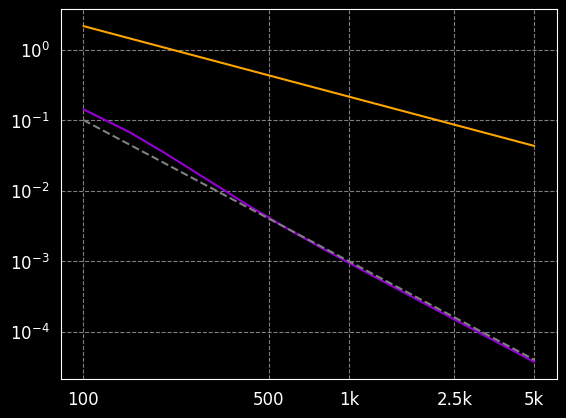

In [47]:
max_errors_per_T = [max(errors) for errors in errors_fidelity_list_full]
max_errorbound_per_T = [max(errors) for errors in error_full_list]

plt.figure()
plt.loglog(T1, max_errors_per_T,'-',color='darkviolet')
plt.loglog(T1, max_errorbound_per_T,'-',color='orange')
plt.loglog(T1, 1000/T1**2, '--', label='Theoretical Slope', color='gray')
plt.xticks([100, 500, 1000, 2500, 5000], ['100', '500', '1k', '2.5k', '5k'])
plt.grid(True, ls="--", alpha=0.5)
plt.show()

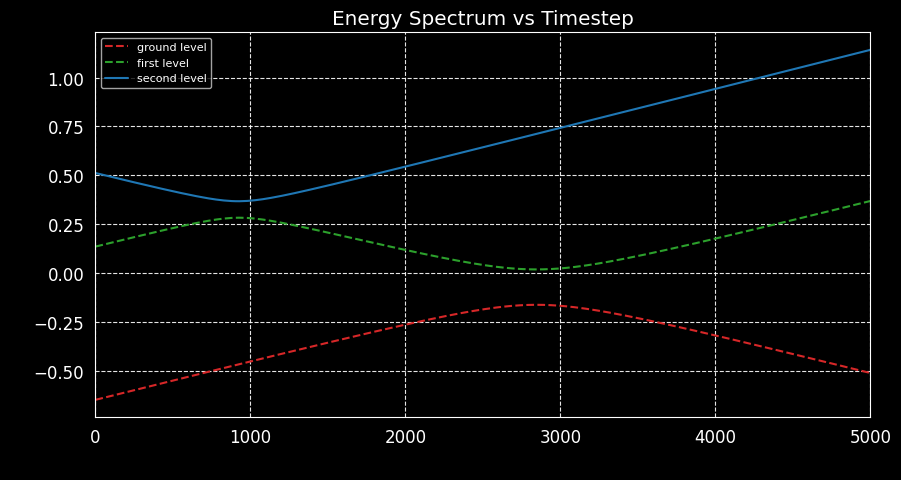

In [48]:
# #Spectrum vs T
plt.figure(figsize=(10,5))
plt.plot(listy[-1], ground_temp, color='tab:red', linestyle='--', label='ground level')
plt.plot(listy[-1],first_temp , color='tab:green', linestyle='--', label='first level')
plt.plot(listy[-1], second_temp, color='tab:blue', linestyle='-', label='second level')
plt.title('Energy Spectrum vs Timestep')
plt.xlabel('Timestep (t)')
plt.ylabel('Energy')
plt.legend(fontsize=8)
plt.autoscale(enable=True, axis='x', tight=True)
plt.grid(linestyle='--',alpha=0.9)


At T =  594.9494949494949


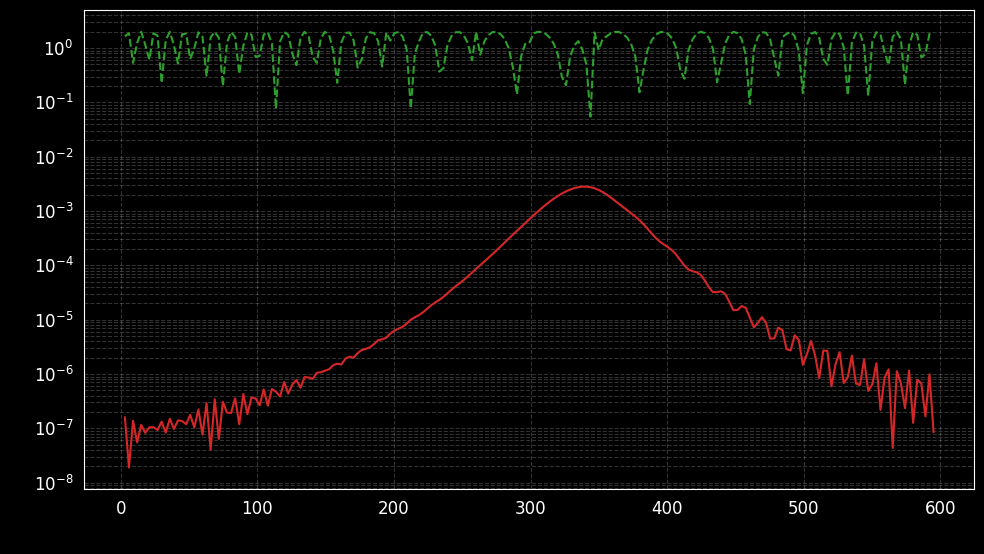

In [62]:
#Visulatization; Comparison of Error Metrics vs Energy Gap
k=10
print('At T = ',T1[k])
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlabel('Time ($t$)', fontsize=12)
ax1.set_ylabel('Error Magnitude (log)', fontsize=12)
# Plotting both error metrics
ax1.plot(listy[k][1:], errors_fidelity_list_full[k][1:], color='tab:red', label='Exact Error')
ax1.plot(listy[k][1:], errors_norm_full[k][1:], color='tab:green', linestyle='--', label='Norm Vector Distance')
ax1.set_yscale('log') # Both metrics are best viewed on a log scale
ax1.grid(True, which="both", ls="--", alpha=0.2)

# Final formatting
fig.tight_layout(rect=[0, 0, 1, 0.95])

# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, facecolor='yellow')

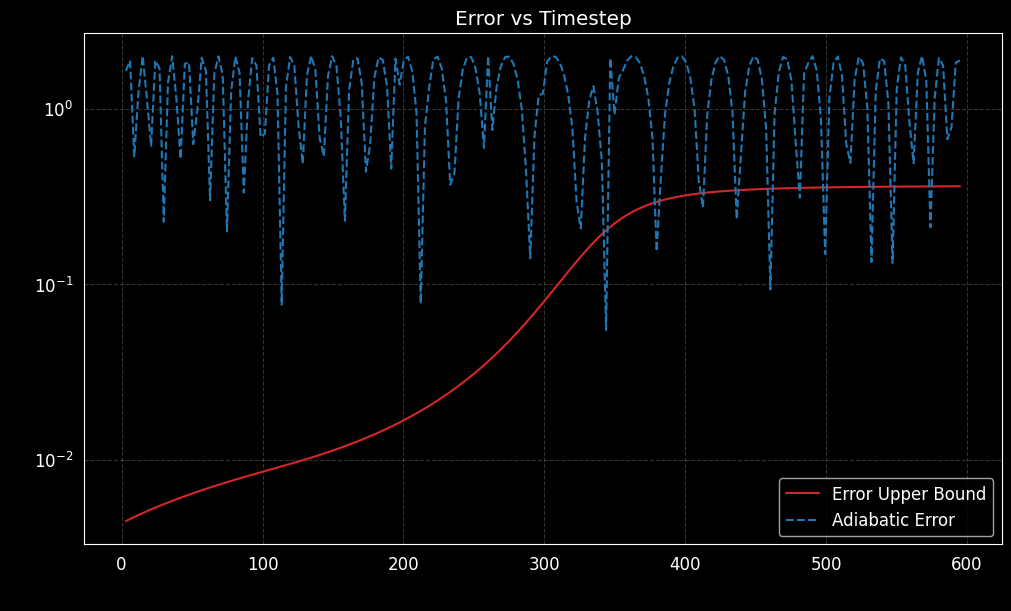

In [63]:
fig, ax = plt.subplots(figsize=(10,6),layout='constrained')
Approximate_Error= ax.plot(listy[k][1:], error_full_list[k][1:], color='tab:red',label='Error Upper Bound')
Ideal_Error=ax.plot(listy[k][1:],  errors_norm_full[k][1:],'--', color='tab:blue',label='Adiabatic Error')
ax.set_ylabel('Error Value(log)', fontsize=12)
ax.set_xlabel('Timestep ($t$)', fontsize=12)
ax.set_yscale('log')
ax.legend()
ax.set_title('Error vs Timestep')
plt.grid(linestyle='--',alpha=0.2)

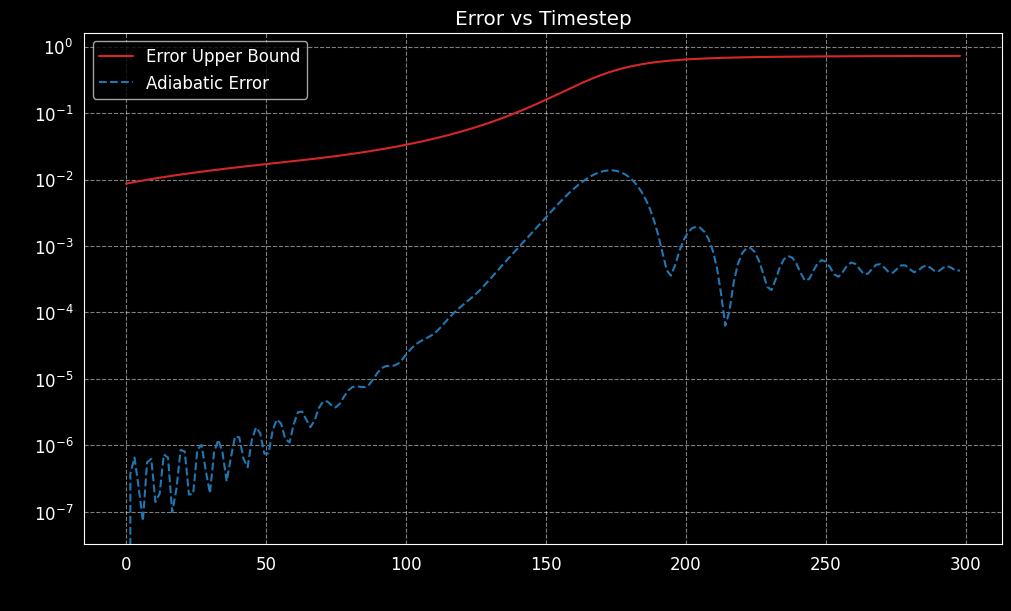

In [61]:
fig, ax = plt.subplots(figsize=(10,6),layout='constrained')
Approximate_Error= ax.plot(listy[k], error_full_list[k], color='tab:red',label='Error Upper Bound')
Ideal_Error=ax.plot(listy[k], errors_fidelity_list_full[k],'--', color='tab:blue',label='Adiabatic Error')
ax.set_ylabel('Error Value(log)', fontsize=12)
ax.set_xlabel('Timestep ($t$)', fontsize=12)
ax.set_yscale('log')
ax.legend()
ax.set_title('Error vs Timestep')
plt.grid(linestyle='--',alpha=0.5)

ANIMATION

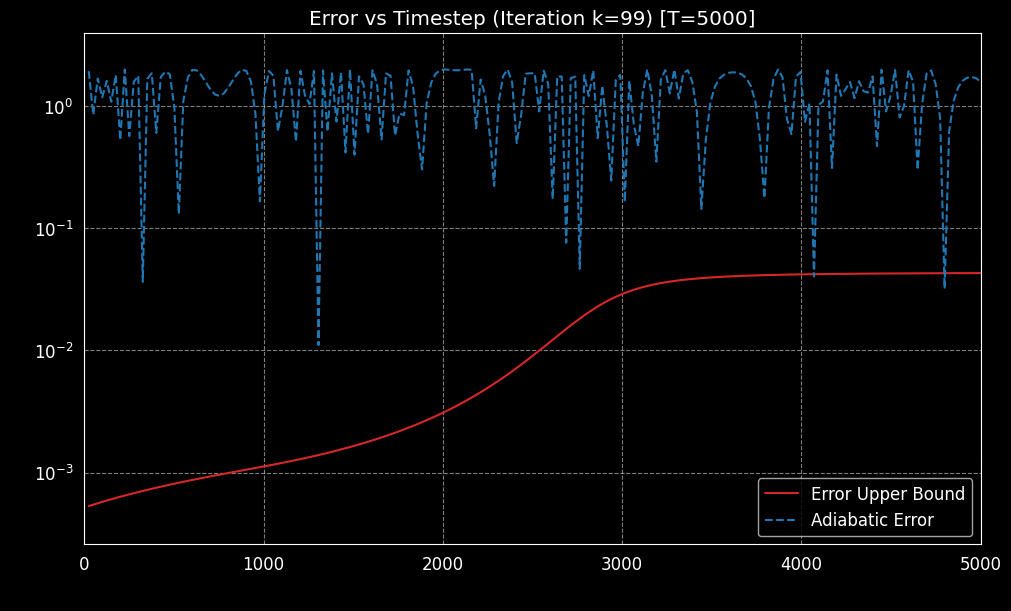

In [174]:
fig, ax = plt.subplots(figsize=(10, 6), layout='constrained')
ax.set_yscale('log')
ax.set_ylabel('Error Value (log)', fontsize=12)
ax.set_xlabel('Timestep ($t$)', fontsize=12)
ax.set_title('Error vs Timestep Animation')
plt.grid(linestyle='--', alpha=0.5)

line_approx, = ax.plot([], [], color='tab:red', label='Error Upper Bound')
line_ideal, = ax.plot([], [], '--', color='tab:blue', label='Adiabatic Error')
ax.legend(loc='lower right')

def update(k):
    ax.set_ylim((min(sorted(list(errors_norm_full[k]))[1],sorted(list(error_full_list[k]))[0])*(1-1/2)), (max(errors_norm_full[k][1:])*(1+1))) #here max() should have the highest value(adiabatic error or ideal error).
    ax.set_xlim(min(listy[0]), max(listy[k]))
    x_data = listy[k][1:]
    y_approx = error_full_list[k][1:]
    y_ideal = errors_norm_full[k][1:]
    line_approx.set_data(x_data, y_approx)
    line_ideal.set_data(x_data, y_ideal)
    ax.set_title(f'Error vs Timestep (Iteration k={k}) [T={round(T1[k])}]')

    return line_approx, line_ideal

ani = FuncAnimation(fig, update, frames=len(error_full_list),
                    interval=100, blit=True)

ani.save(r'/home/pravin/Desktop/Physik 2025/AQC Project/error_animation_updated.gif', writer='pillow')
plt.show()

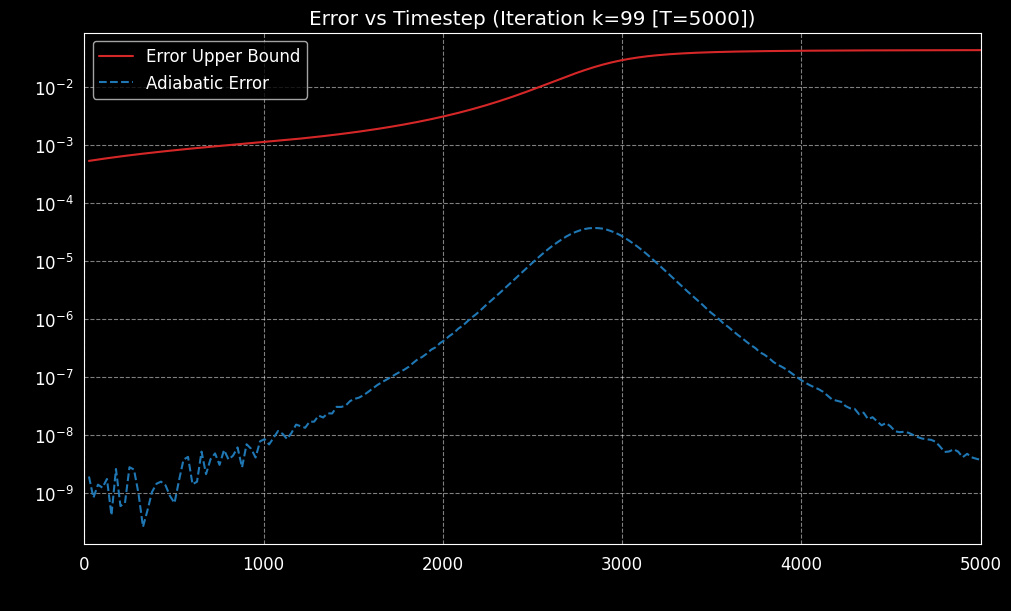

In [132]:
fig, ax = plt.subplots(figsize=(10,6),layout='constrained')
ax.set_yscale('log')
ax.set_ylabel('Error Value (log)', fontsize=12)
ax.set_xlabel('Timestep ($t$)', fontsize=12)
ax.set_title('Error vs Timestep Animation')
plt.grid(linestyle='--', alpha=0.5)

line_approx, = ax.plot([], [], color='tab:red', label='Error Upper Bound')
line_ideal, = ax.plot([], [], '--', color='tab:blue', label='Adiabatic Error')
ax.legend()
ax.set_xlim(min(listy[0]), max(listy[-1]))
# ax.set_ylim(1e-8, 5)

def update(k):
    ax.set_ylim((min(errors_fidelity_list_full[k][1:])*(1-1/2)), (max(error_full_list[k][1:])*(1+1)))
    ax.set_xlim(min(listy[0]), max(listy[k]))
    x_data = listy[k][1:]
    y_approx = error_full_list[k][1:]
    y_ideal = errors_fidelity_list_full[k][1:]
    line_approx.set_data(x_data, y_approx)
    line_ideal.set_data(x_data, y_ideal)
    ax.set_title(f'Error vs Timestep (Iteration k={k} [T={round(T1[k])}])')

    return line_approx, line_ideal

ani = FuncAnimation(fig, update, frames=len(error_full_list),
                    interval=100, blit=True)

ani.save(r'/home/pravin/Desktop/Physik 2025/AQC Project/error_animation1.gif', writer='pillow')
plt.show()

TO BE DELETED

In [ ]:
#for f vs T
f_values = [f(t, args) for t in t_list]
fidelity_values = [1 - err for err in errors_fidelity]
plt.figure()
plt.plot(t_list, f_values)
plt.title('Function f vs Timestep')
plt.xlabel('Timestep (t)')
plt.ylabel('f(t)')
plt.grid()
plt.show()

In [ ]:
max_error=np.argmax(error)
max_error_1=np.argmax(errors_fidelity)
time_at_error_peak=t_list[max_error]
error_value_at_peak=errors_fidelity[max_error_1]
error_upper_bound_value_at_peak=error[max_error]
Difference_in_error=error_value_at_peak-error_upper_bound_value_at_peak

print('Peak Error Time: ',time_at_error_peak)
print('Error: ',error_value_at_peak)
print('Upper Bound Error: ',error_upper_bound_value_at_peak)
print('Difference between Error and EUB: ',Difference_in_error)
